## Import libraries

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib as plt
import seaborn as sns

## Load Data

In [2]:
crime = pd.read_csv('crimes.csv')

First, I want to get rid off 2026 data.

In [3]:
crime = crime[crime['Year'] < 2026]

## Exploring

I want to know the dimensions of the data frame:

In [4]:
crime.shape

(8475935, 22)

How many observations do we have per year?

In [5]:
observations = {}
for year in crime['Year'].unique():
    count = crime['Year'][crime['Year'] == year].count()
    observations[year] = count

Text(0.5, 1.0, 'Number of observations per year')

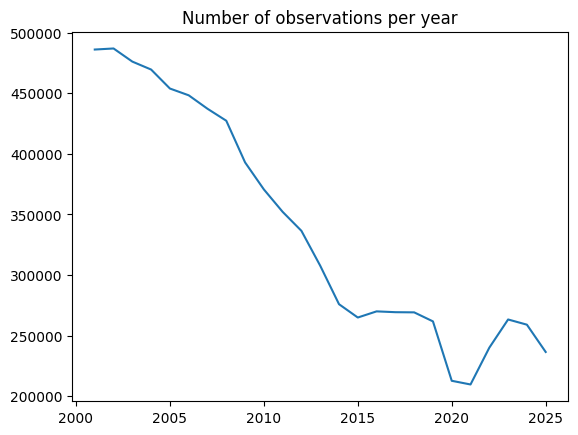

In [6]:
map_1 = sns.lineplot(x = observations.keys(), y = observations.values())
map_1.set_title('Number of observations per year')

Chicago might be doing something right as crime incidence has been decreasing for 25 years. We see a sharp fall from 2019 to 2021, most probably because of covid. In 2023 crime incidence went back up to previous levels, followed by another minimum in 2025.

## Cleaning

I will use Huizhao's code to find out the number of missing values.

In [8]:
len(crime)

8475935

In [7]:
missing = crime.isnull().sum()
missing_pct = (missing / len(crime) * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
}).sort_values("missing_pct", ascending=False)

missing_summary

,missing_count,missing_pct
Ward,614818,7.25
Community Area,613685,7.24
Location,94625,1.12
Y Coordinate,94625,1.12
Longitude,94625,1.12
Latitude,94625,1.12
X Coordinate,94625,1.12
Location Description,15504,0.18
Primary Type,0,0.00
IUCR,0,0.00


In [ ]:
#crime['fecha'] = pd.to_datetime(crime['Date'], format='%m/%d/%Y %I:%M:%S %p')
#crime['fecha'] = crime['fecha'].dt.strftime('%d/%m/%Y %H:%M:%S')